# Ponds Data — Extensive Descriptive Statistics

Dataset: `Ponds data.csv` (Kaggle)

Multiple stations, sub-daily readings, 2022.

Variables: NITRATE, PH, AMMONIA, TEMP, DO, TURBIDITY, MANGANESE.

Label: binary outcome variable for water quality classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

# Paths
DATA_PATH = '../data/kaggle/Ponds data.csv'
OUTPUT_DIR = './descriptives'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DO_THRESHOLD = 3.0  # mg/L — hypoxia threshold used in welfare models

print(f"Output directory: {OUTPUT_DIR}")
print(f"Data path: {DATA_PATH}")

Output directory: ./descriptives
Data path: ../data/kaggle/Ponds data.csv


## 1. Load & Parse

In [2]:
df = pd.read_csv(DATA_PATH)

# Convert sensor columns to numeric (handle any non-numeric values)
for col in ['NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY', 'MANGANESE(mg/l)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S', dayfirst=True)
df = df.sort_values('DateTime').reset_index(drop=True)

# Derived time columns
df['date_only'] = df['DateTime'].dt.normalize()
df['month'] = df['DateTime'].dt.month
df['month_name'] = df['DateTime'].dt.strftime('%b')
df['hour'] = df['DateTime'].dt.hour
df['dow'] = df['DateTime'].dt.day_name()
df['week'] = df['DateTime'].dt.isocalendar().week

# Hypoxia flag
df['low_DO'] = (df['DO'] < DO_THRESHOLD).astype(int)

# Label encoding
df['label_name'] = df['label'].map({0: 'Good', 1: 'Poor', -1: 'Unknown'}).fillna('Unknown')

SENSORS = ['NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY', 'MANGANESE(mg/l)']

print(f"Shape: {df.shape}")
print(f"DateTime range: {df['DateTime'].min()} → {df['DateTime'].max()}")
df.head(5)

Shape: (74796, 20)
DateTime range: 2022-02-01 00:00:00 → 2023-01-21 23:40:00


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label,DateTime,date_only,month,month_name,hour,dow,week,low_DO,label_name
0,Station3,01-02-2022,00:00:00,0.95931,6.10346,0.051164,23.515591,10.092118,34.325856,0.644899,0.0,2022-02-01 00:00:00,2022-02-01,2.0,Feb,0.0,Tuesday,5,0,Good
1,station1,01-02-2022,00:00:00,0.90000,5.90000,0.049000,22.670000,10.400000,32.800000,0.660000,0.0,2022-02-01 00:00:00,2022-02-01,2.0,Feb,0.0,Tuesday,5,0,Good
2,Station2,01-02-2022,00:00:00,29.17200,5.65600,0.022088,22.911680,8.218660,29.959200,0.644800,0.0,2022-02-01 00:00:00,2022-02-01,2.0,Feb,0.0,Tuesday,5,0,Good
3,station1,01-02-2022,00:20:00,28.60000,5.60000,0.022000,22.640000,8.300000,29.200000,0.650000,0.0,2022-02-01 00:20:00,2022-02-01,2.0,Feb,0.0,Tuesday,5,0,Good
4,Station3,01-02-2022,00:20:00,30.48474,6.91670,0.022972,23.484472,8.054287,30.558384,0.635128,0.0,2022-02-01 00:20:00,2022-02-01,2.0,Feb,0.0,Tuesday,5,0,Good


## 2. Dataset Overview

In [3]:
print("=== Stations ===")
print(df['station'].value_counts().sort_index())
print(f"\nNumber of unique stations: {df['station'].nunique()}")
print(f"\nDate range: {df['DateTime'].min()} → {df['DateTime'].max()}")
print(f"Span: {(df['DateTime'].max() - df['DateTime'].min()).days} days")
print(f"\nTotal readings: {len(df):,}")
print(f"\nReadings per station:")
print(df['station'].value_counts().sort_index())

=== Stations ===
station
Station2    25498
Station3    25461
station1    23799
Name: count, dtype: int64

Number of unique stations: 3

Date range: 2022-02-01 00:00:00 → 2023-01-21 23:40:00
Span: 354 days

Total readings: 74,796

Readings per station:
station
Station2    25498
Station3    25461
station1    23799
Name: count, dtype: int64


In [4]:
# Reading interval check
diffs = df.groupby('station')['DateTime'].diff().dt.total_seconds().div(60).dropna()
print(f"Reading interval (minutes) — most common: {diffs.mode()[0]:.0f}")
print(f"\nReading interval statistics:")
print(diffs.describe().round(1))

Reading interval (minutes) — most common: 20

Reading interval statistics:
count    74704.0
mean        20.0
std          5.4
min         20.0
25%         20.0
50%         20.0
75%         20.0
max       1220.0
Name: DateTime, dtype: float64


In [5]:
print("=== Missing Values ===")
miss = df[SENSORS].isnull().sum()
miss_pct = (df[SENSORS].isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'missing_count': miss, 'missing_%': miss_pct})
print(missing_df)
print(f"\nLabel distribution:")
print(df['label_name'].value_counts())

=== Missing Values ===
                 missing_count  missing_%
NITRATE(PPM)                44       0.06
PH                          40       0.05
AMMONIA(mg/l)               38       0.05
TEMP                        44       0.06
DO                          48       0.06
TURBIDITY                   38       0.05
MANGANESE(mg/l)             63       0.08

Label distribution:
label_name
Good       61340
Poor       13418
Unknown       38
Name: count, dtype: int64


## 3. Global Summary Statistics

In [6]:
summary = df[SENSORS].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).T.round(3)
summary['skew'] = df[SENSORS].skew().round(3)
summary['kurtosis'] = df[SENSORS].kurtosis().round(3)
summary['CV%'] = (df[SENSORS].std() / df[SENSORS].mean() * 100).round(1)
print("Global Summary Statistics (all stations combined):")
print(summary)

Global Summary Statistics (all stations combined):
                   count    mean     std     min      5%     10%     25%  \
NITRATE(PPM)     74752.0  38.676  35.755   0.000   3.790   6.885  16.000   
PH               74756.0   6.543   1.110   4.500   4.942   5.173   5.700   
AMMONIA(mg/l)    74758.0   0.096   0.160   0.001   0.017   0.020   0.030   
TEMP             74752.0  27.226   5.972   0.000  18.604  19.844  22.922   
DO               74748.0  10.760   5.510   0.000   3.900   4.894   6.567   
TURBIDITY        74758.0  31.589  11.630  10.200  16.633  18.400  22.862   
MANGANESE(mg/l)  74733.0   0.981   0.771   0.200   0.295   0.351   0.554   

                    50%     75%      90%      95%      max   skew  kurtosis  \
NITRATE(PPM)     27.545  39.492  102.121  125.838  153.395  1.556     1.492   
PH                6.400   7.303    8.253    8.619    9.007  0.379    -0.693   
AMMONIA(mg/l)     0.045   0.103    0.153    0.320    1.872  5.215    32.701   
TEMP             26.819 

## 4. Per-Station Summary

In [ ]:
for sensor in SENSORS:
    print(f"\n{sensor}:")
    station_stats = df.groupby('station')[sensor].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
    print(station_stats)

In [ ]:
# Kruskal-Wallis test: do stations differ significantly for each sensor?
print("Kruskal-Wallis H-test (station differences)\n")
for col in SENSORS:
    grps = [g[col].dropna().values for _, g in df.groupby('station')]
    if len(grps) > 1:
        h, p = stats.kruskal(*grps)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {col:<22}  H={h:8.1f}  p={p:.2e}  {sig}")

## 5. Distributions — KDE by Station

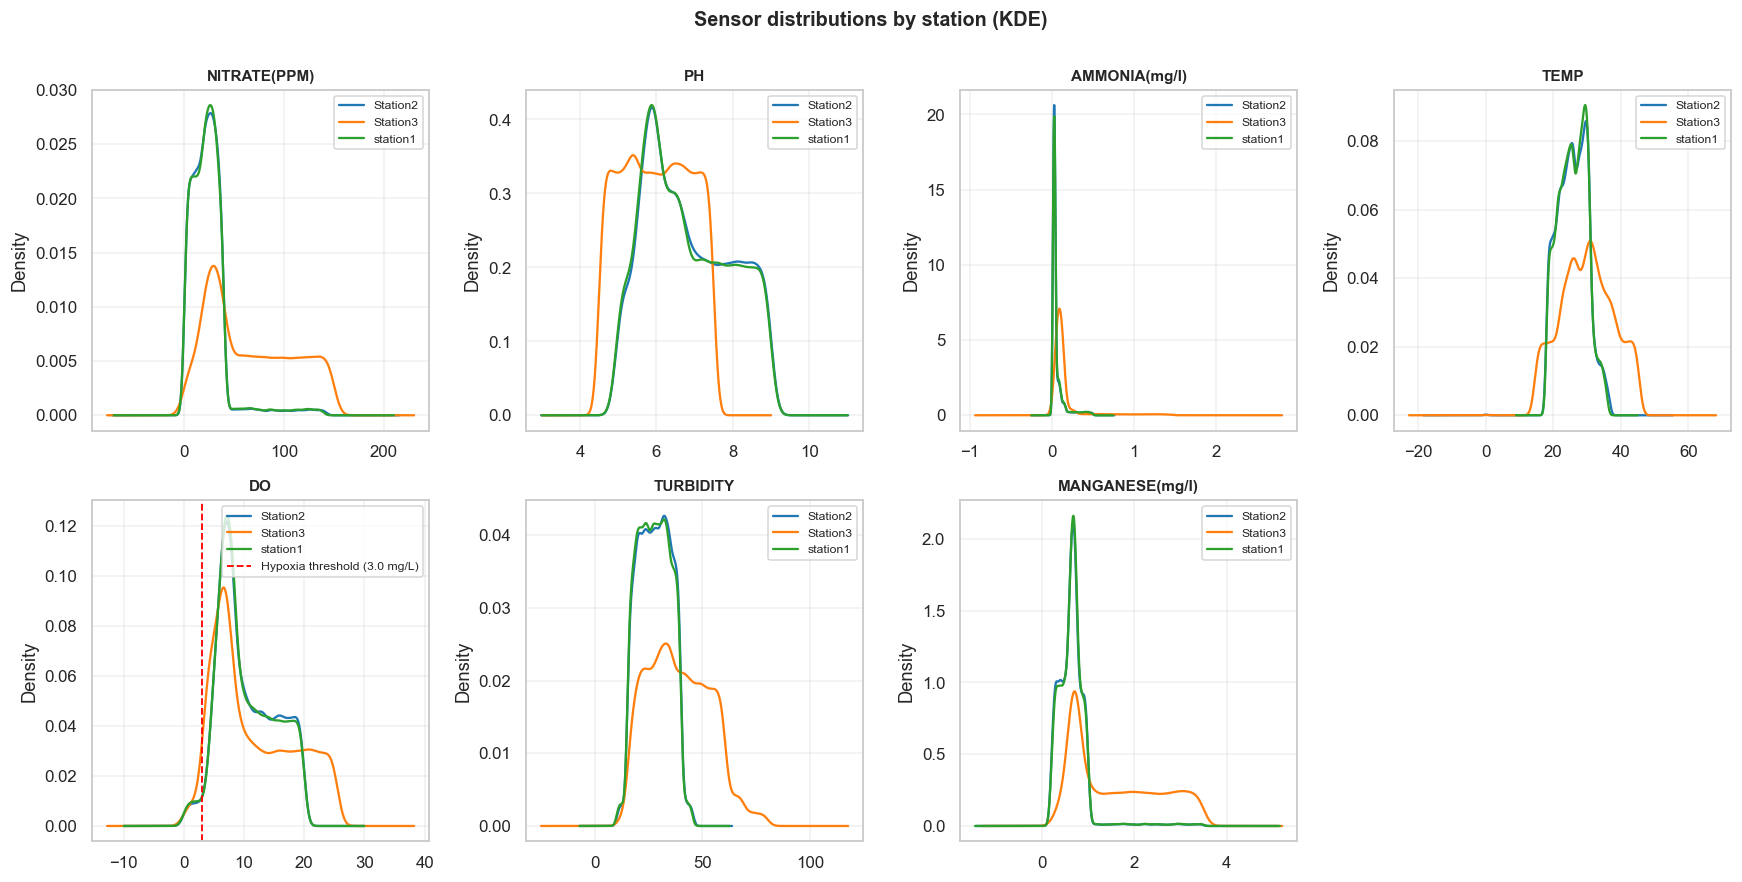

Saved: ./descriptives/01_kde_by_station.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(SENSORS):
    ax = axes[i]
    for stn, grp in df.groupby('station'):
        grp[col].dropna().plot.kde(ax=ax, label=stn, linewidth=1.5)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

# DO threshold line
if 'DO' in SENSORS:
    do_ax = axes[SENSORS.index('DO')]
    do_ax.axvline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'Hypoxia threshold ({DO_THRESHOLD} mg/L)')
    do_ax.legend(fontsize=8, loc='best')

axes[-1].set_visible(False)
fig.suptitle('Sensor distributions by station (KDE)', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_kde_by_station.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/01_kde_by_station.png")

## 6. Box Plots by Station

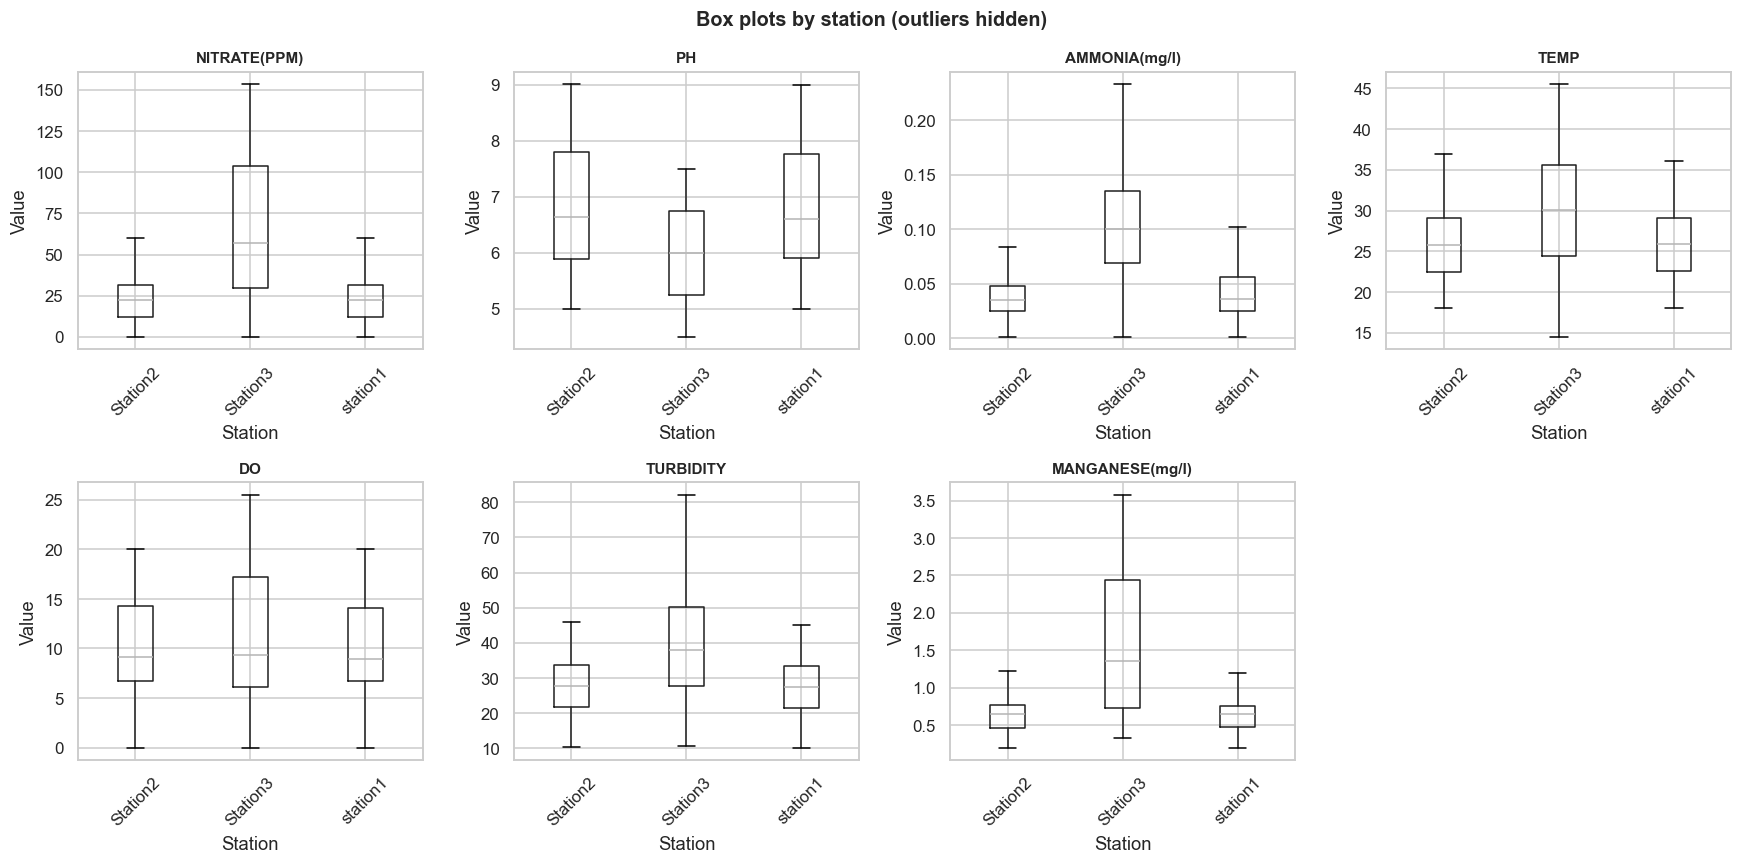

Saved: ./descriptives/02_boxplots_by_station.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(SENSORS):
    ax = axes[i]
    df.boxplot(column=col, by='station', ax=ax, showfliers=False)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Station')
    ax.set_ylabel('Value')
    plt.sca(ax)
    plt.xticks(rotation=45)

axes[-1].set_visible(False)
fig.suptitle('Box plots by station (outliers hidden)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_boxplots_by_station.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/02_boxplots_by_station.png")

## 7. Temporal Patterns — Daily Means

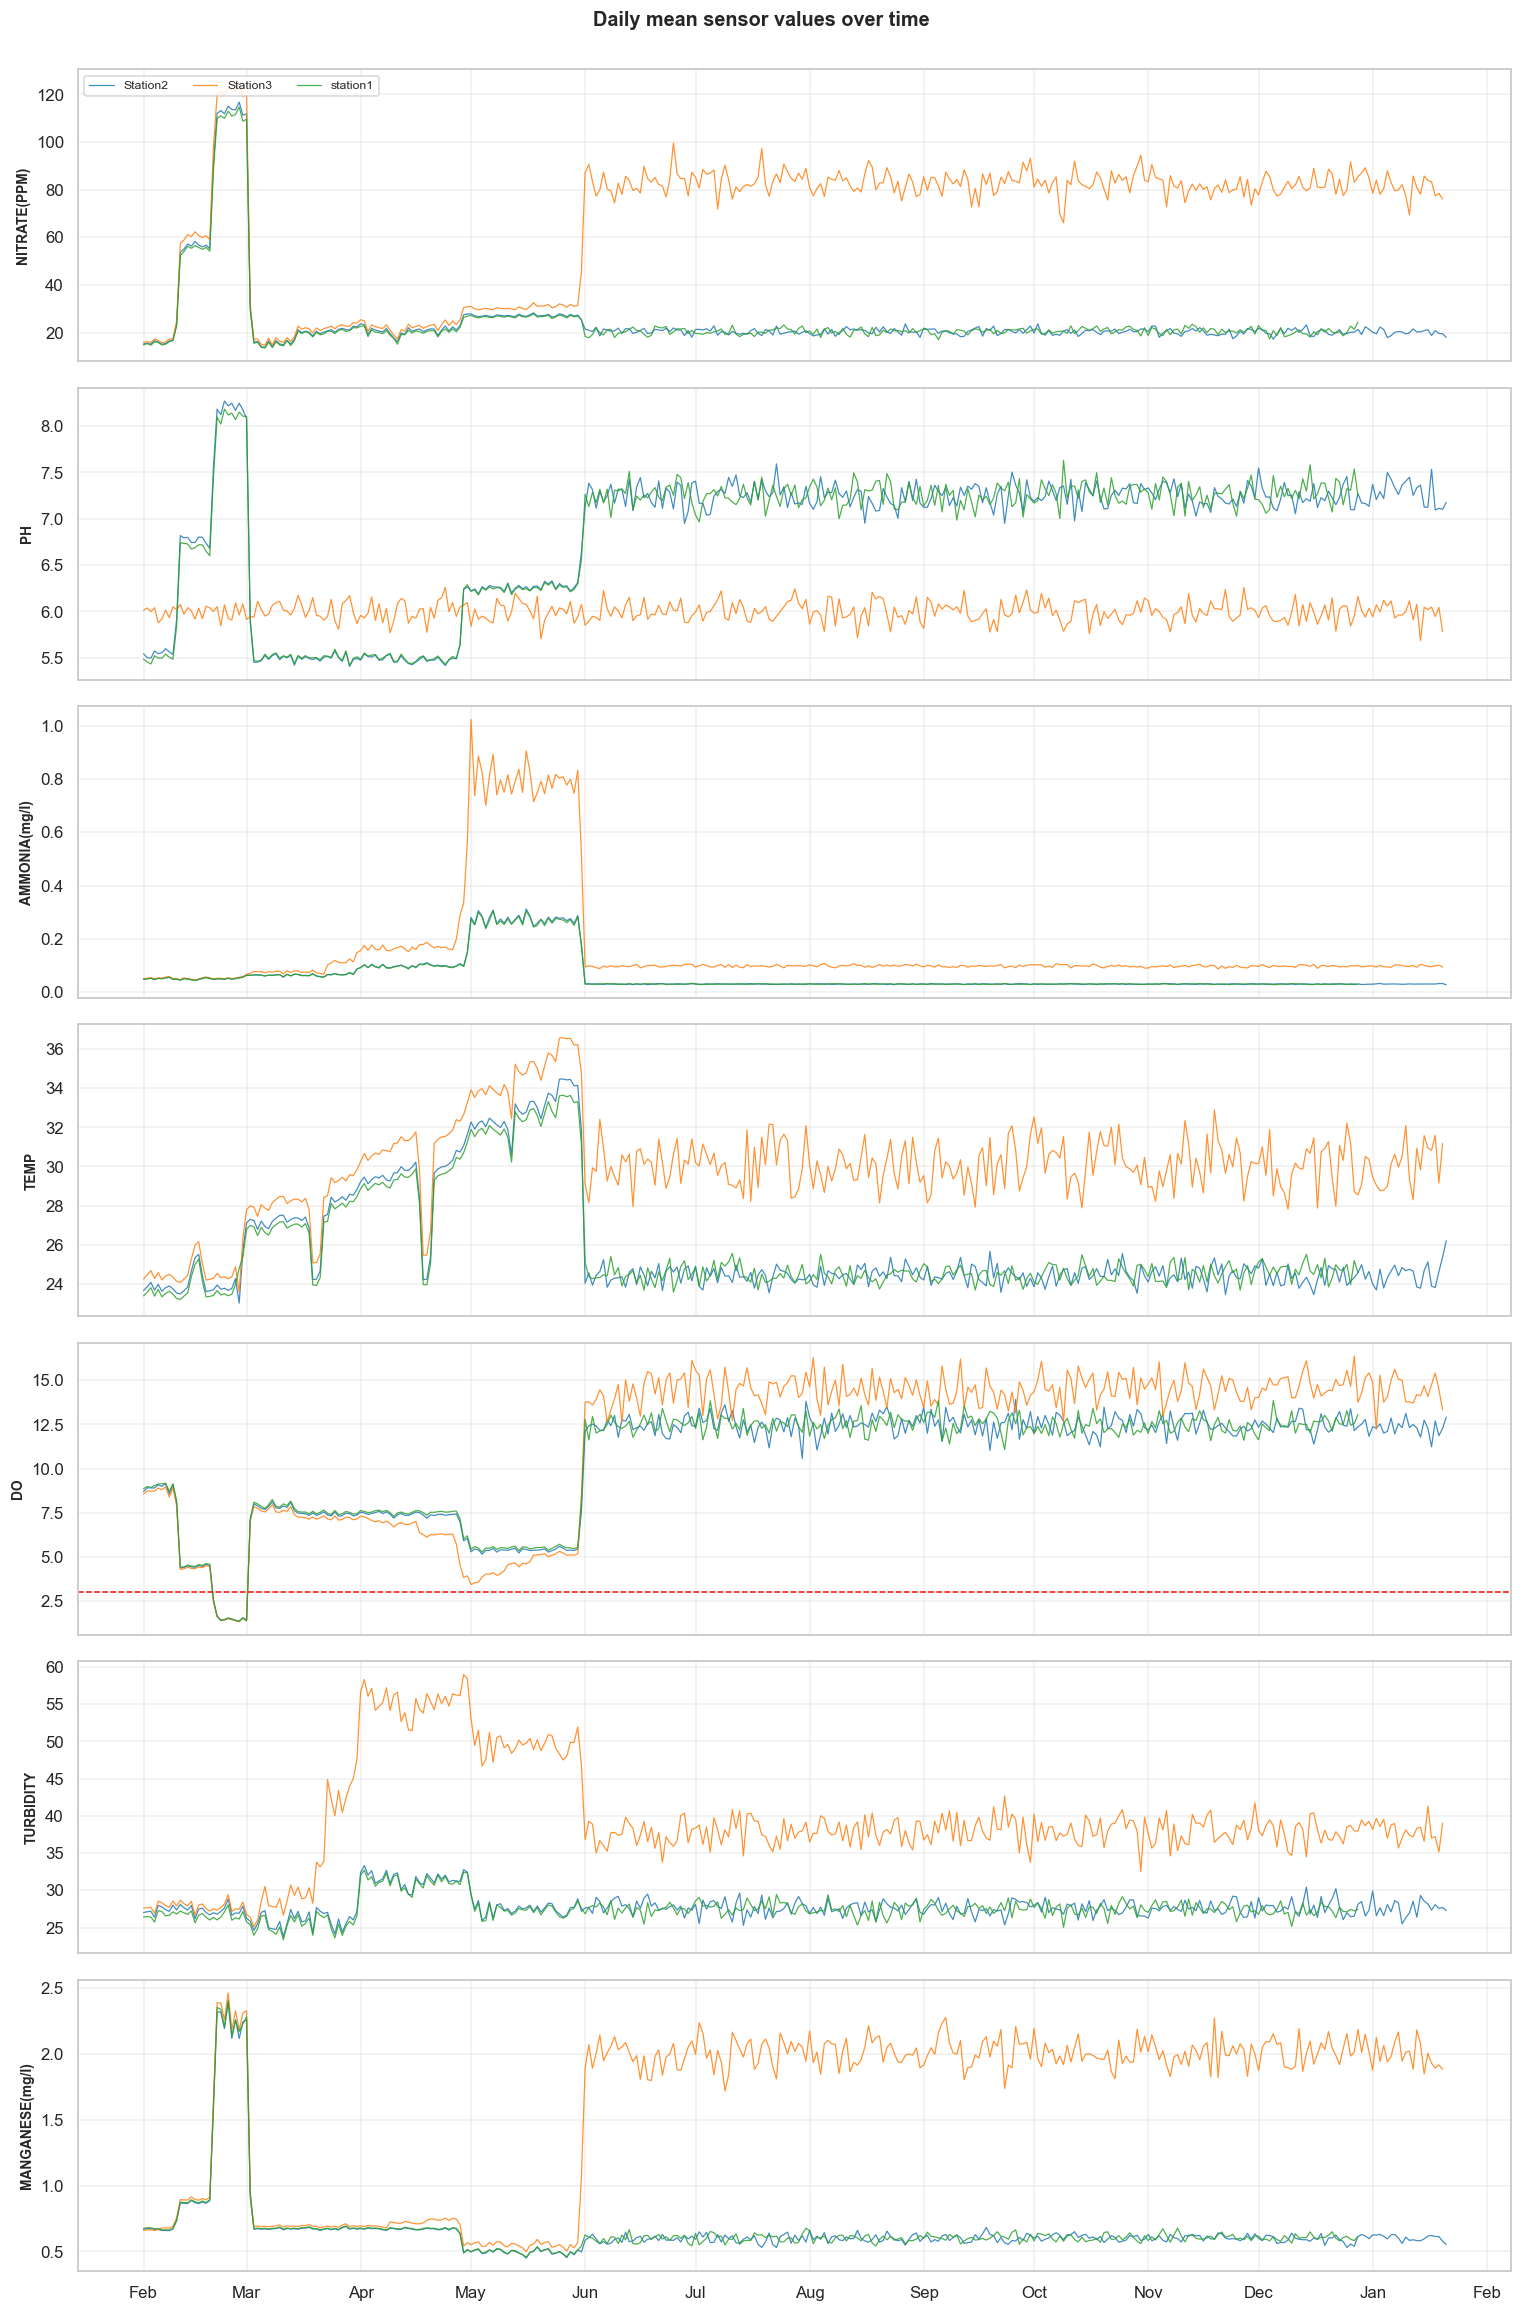

Saved: ./descriptives/03_daily_means_timeseries.png


In [9]:
# Daily means per station
daily = df.groupby(['station', 'date_only'])[SENSORS].mean().reset_index()

fig, axes = plt.subplots(len(SENSORS), 1, figsize=(14, 3 * len(SENSORS)), sharex=True)

for ax, col in zip(axes, SENSORS):
    for stn, grp in daily.groupby('station'):
        ax.plot(grp['date_only'], grp[col], linewidth=0.8, label=stn, alpha=0.85)
    ax.set_ylabel(col, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Hypoxia threshold')
    if col == 'NITRATE(PPM)':
        ax.legend(fontsize=8, ncol=3, loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.suptitle('Daily mean sensor values over time', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_daily_means_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/03_daily_means_timeseries.png")

## 8. Monthly Patterns

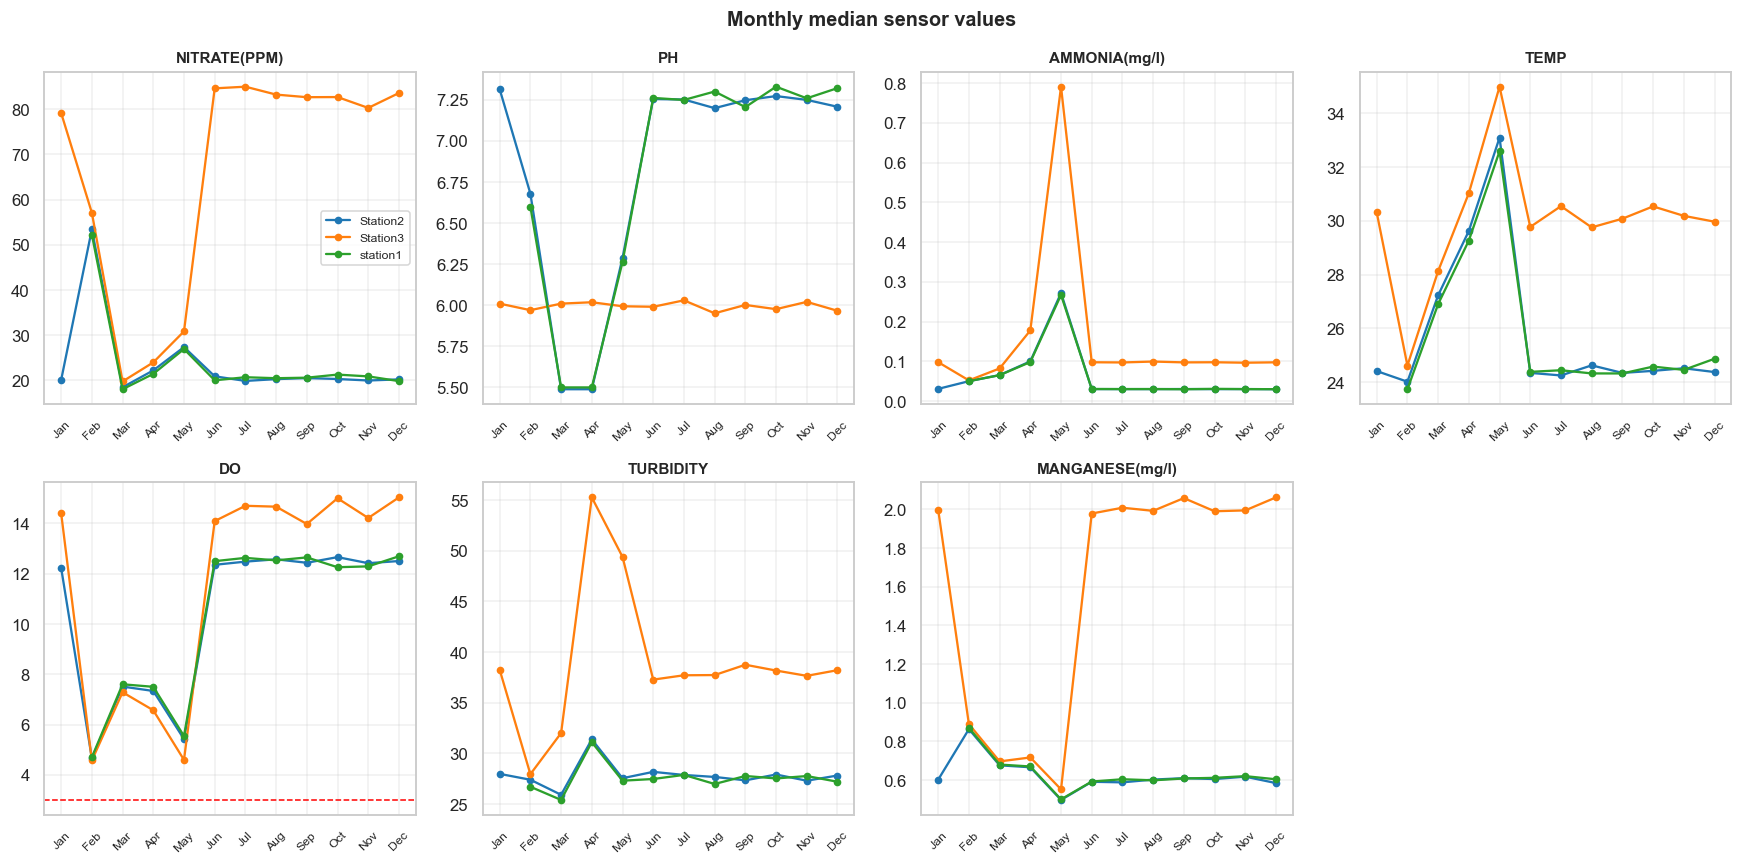

Saved: ./descriptives/04_monthly_patterns.png


In [10]:
# Monthly medians
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = df.groupby(['month_name', 'station'])[SENSORS].median().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(SENSORS):
    ax = axes[i]
    for stn, grp in monthly.groupby('station'):
        grp_sorted = grp.set_index('month_name').reindex(MONTH_ORDER)
        ax.plot(range(len(MONTH_ORDER)), grp_sorted[col], marker='o', markersize=4, label=stn)
    ax.set_xticks(range(len(MONTH_ORDER)))
    ax.set_xticklabels(MONTH_ORDER, rotation=45, fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1)

if 'NITRATE(PPM)' in SENSORS:
    axes[SENSORS.index('NITRATE(PPM)')].legend(fontsize=8, loc='best')

axes[-1].set_visible(False)
fig.suptitle('Monthly median sensor values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_monthly_patterns.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/04_monthly_patterns.png")

## 9. Diurnal (Hour-of-Day) Patterns

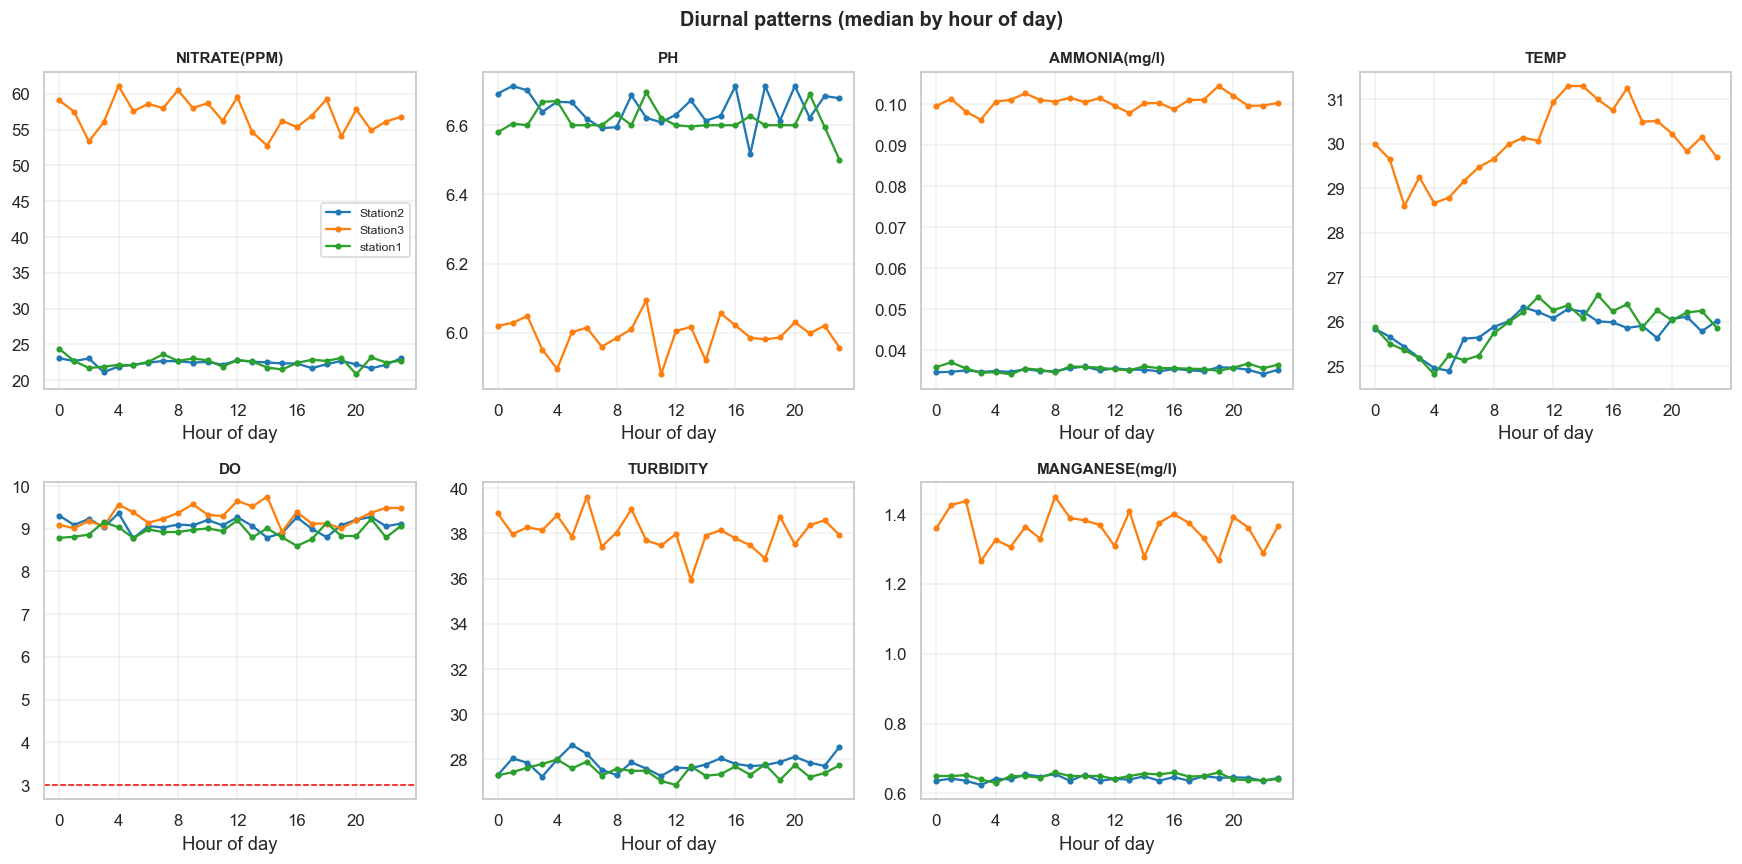

Saved: ./descriptives/05_diurnal_patterns.png


In [11]:
# Diurnal (hour-of-day) patterns
hourly = df.groupby(['hour', 'station'])[SENSORS].median().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(SENSORS):
    ax = axes[i]
    for stn, grp in hourly.groupby('station'):
        ax.plot(grp['hour'], grp[col], marker='.', markersize=6, label=stn)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_xlim(-1, 24)
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)
    if col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1)

if 'NITRATE(PPM)' in SENSORS:
    axes[SENSORS.index('NITRATE(PPM)')].legend(fontsize=8, loc='best')

axes[-1].set_visible(False)
fig.suptitle('Diurnal patterns (median by hour of day)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_diurnal_patterns.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/05_diurnal_patterns.png")

## 10. Dissolved Oxygen (DO) Deep-Dive

In [12]:
# Prevalence of low-DO events
print(f"Readings with DO < {DO_THRESHOLD} mg/L (hypoxia):")
lo = df.groupby('station')['low_DO'].agg(['sum', 'mean']).rename(columns={'sum': 'count', 'mean': 'fraction'})
lo['fraction_%'] = (lo['fraction'] * 100).round(1)
print(lo)

print(f"\nGlobal: {df['low_DO'].sum()} / {len(df)} readings ({df['low_DO'].mean()*100:.1f}%)")

Readings with DO < 3.0 mg/L (hypoxia):
          count  fraction  fraction_%
station                              
Station2    721  0.028277         2.8
Station3    803  0.031538         3.2
station1    700  0.029413         2.9

Global: 2224 / 74796 readings (3.0%)


In [13]:
# DO by label
print("\nDO statistics by label:")
do_by_label = df.groupby('label_name')['DO'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print(do_by_label)


DO statistics by label:
            count   mean  median   std  min    max
label_name                                        
Good        61330  10.50    8.76  4.91  0.0  25.50
Poor        13418  11.96   11.58  7.57  0.0  25.49
Unknown         0    NaN     NaN   NaN  NaN    NaN


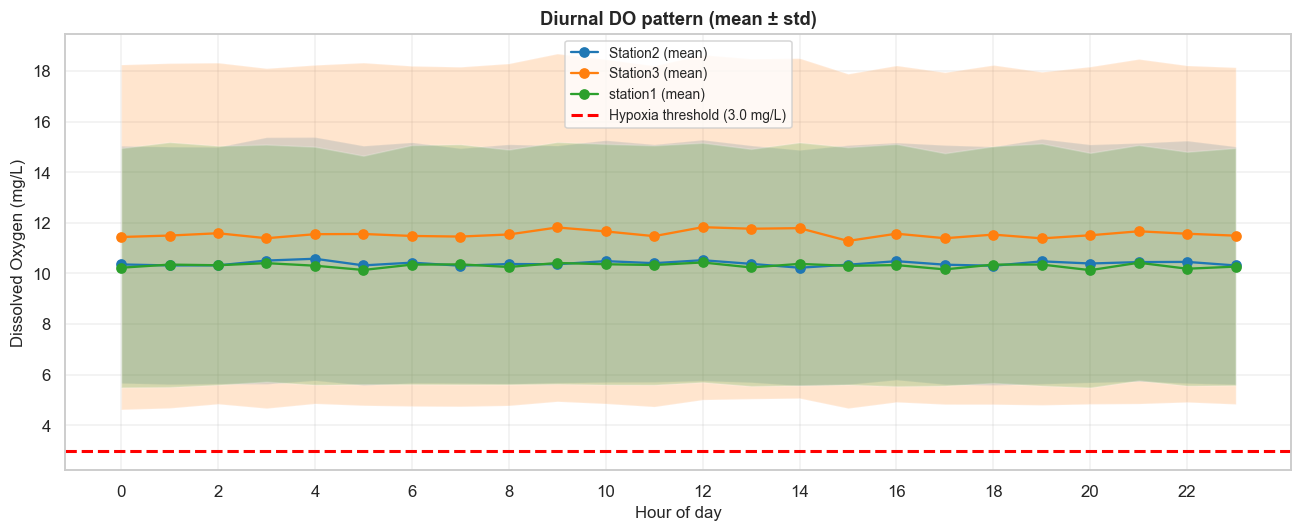

Saved: ./descriptives/06_do_diurnal_detail.png


In [14]:
# Hourly DO distribution
fig, ax = plt.subplots(figsize=(12, 5))

for stn, grp in df.groupby('station'):
    hourly_do = grp.groupby('hour')['DO'].agg(['mean', 'std'])
    ax.plot(hourly_do.index, hourly_do['mean'], marker='o', markersize=6, label=f'{stn} (mean)')
    ax.fill_between(hourly_do.index, 
                    hourly_do['mean'] - hourly_do['std'],
                    hourly_do['mean'] + hourly_do['std'],
                    alpha=0.2)

ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Hypoxia threshold ({DO_THRESHOLD} mg/L)')
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Dissolved Oxygen (mg/L)', fontsize=11)
ax.set_title('Diurnal DO pattern (mean ± std)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_do_diurnal_detail.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/06_do_diurnal_detail.png")

## 11. Correlations Within Stations

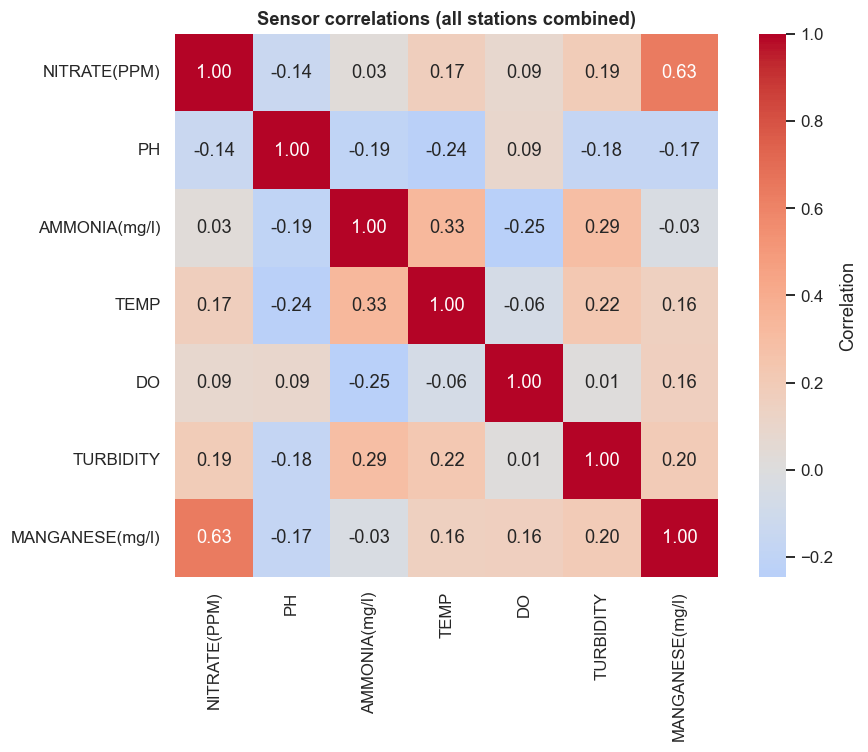

Saved: ./descriptives/07_correlation_heatmap.png


In [15]:
# Global correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[SENSORS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Sensor correlations (all stations combined)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/07_correlation_heatmap.png")

In [17]:
# Per-station correlations
for stn in sorted(df['station'].unique(), key=str):
    print(f"\n=== Station {stn} Correlations ===")
    stn_corr = df[df['station'] == stn][SENSORS].corr()
    print(stn_corr.round(2))


=== Station Station2 Correlations ===
                 NITRATE(PPM)    PH  AMMONIA(mg/l)  TEMP    DO  TURBIDITY  \
NITRATE(PPM)             1.00  0.15           0.06 -0.01 -0.33      -0.01   
PH                       0.15  1.00          -0.26 -0.26  0.23      -0.03   
AMMONIA(mg/l)            0.06 -0.26           1.00  0.50 -0.37       0.02   
TEMP                    -0.01 -0.26           0.50  1.00 -0.27       0.02   
DO                      -0.33  0.23          -0.37 -0.27  1.00      -0.01   
TURBIDITY               -0.01 -0.03           0.02  0.02 -0.01       1.00   
MANGANESE(mg/l)          0.60  0.12          -0.08 -0.08 -0.26      -0.00   

                 MANGANESE(mg/l)  
NITRATE(PPM)                0.60  
PH                          0.12  
AMMONIA(mg/l)              -0.08  
TEMP                       -0.08  
DO                         -0.26  
TURBIDITY                  -0.00  
MANGANESE(mg/l)             1.00  

=== Station Station3 Correlations ===
                 NITRATE(

## 12. Quality by Label

In [18]:
# Sensor values by label
print("Sensor statistics by label:\n")
for col in SENSORS:
    print(f"\n{col}:")
    label_stats = df.groupby('label_name')[col].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
    print(label_stats)

Sensor statistics by label:


NITRATE(PPM):
            count   mean  median    std   min    max
label_name                                          
Good        61334  28.20   24.19  25.16  0.00  153.4
Poor        13418  86.54   89.25  37.88  2.88  152.8
Unknown         0    NaN     NaN    NaN   NaN    NaN

PH:
            count  mean  median   std  min   max
label_name                                      
Good        61338  6.61    6.44  1.11  4.5  9.00
Poor        13418  6.24    6.21  1.05  4.5  9.01
Unknown         0   NaN     NaN   NaN  NaN   NaN

AMMONIA(mg/l):
            count  mean  median   std  min   max
label_name                                      
Good        61340  0.10    0.04  0.18  0.0  1.87
Poor        13418  0.09    0.09  0.05  0.0  1.48
Unknown         0   NaN     NaN   NaN  NaN   NaN

TEMP:
            count   mean  median   std    min   max
label_name                                         
Good        61340  26.84   26.79  5.23  14.51  45.5
Poor        13412

## 13. Scatter Plots — Key Relationships

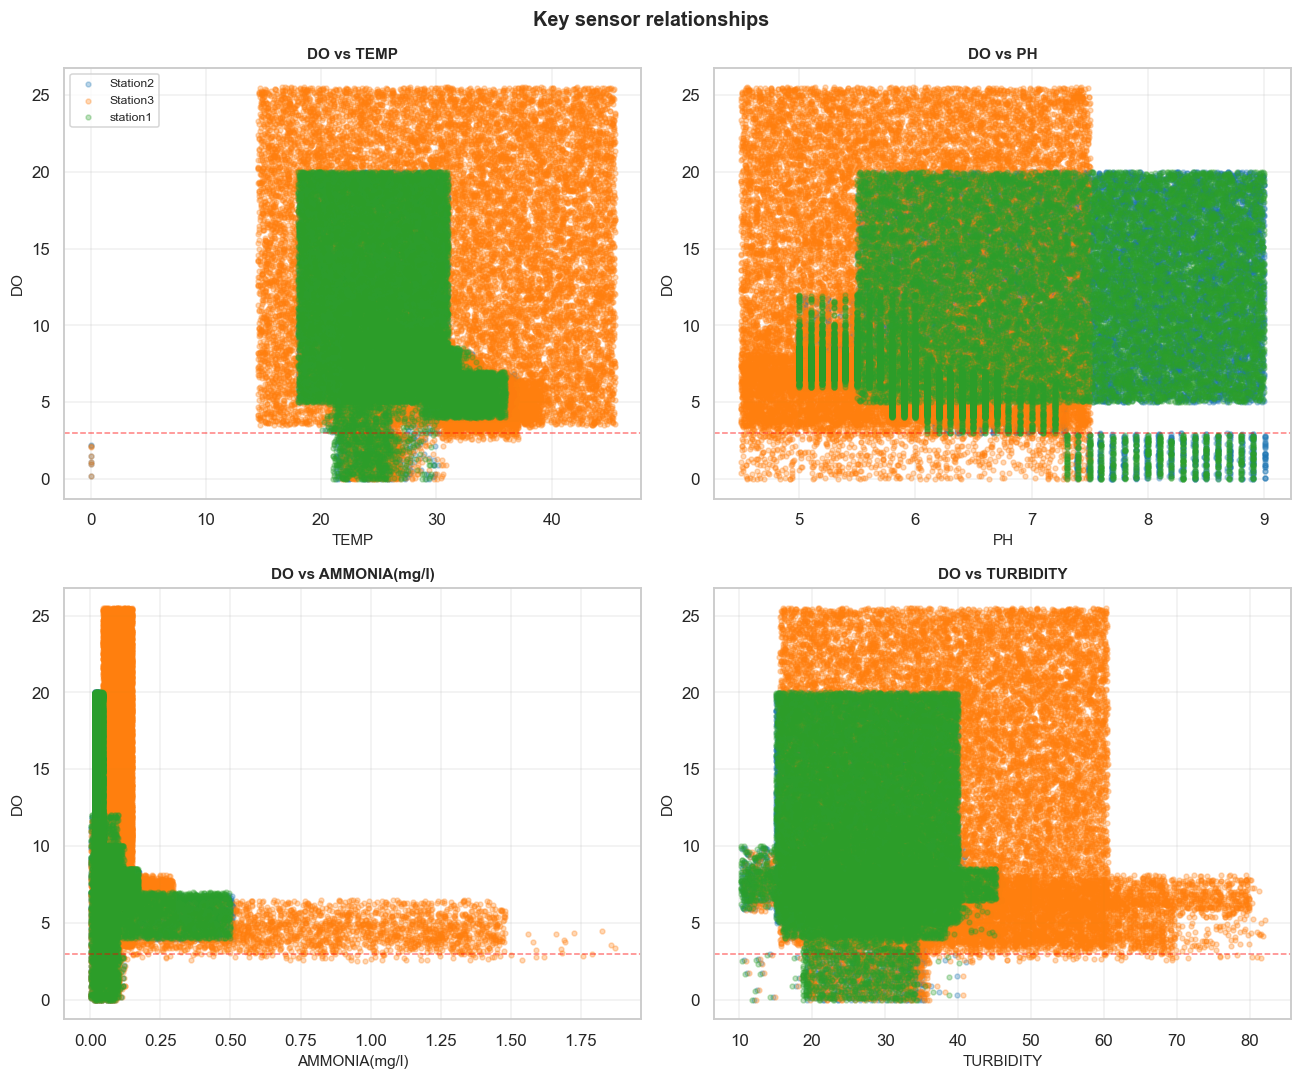

Saved: ./descriptives/09_scatter_relationships.png


In [19]:
# DO vs other key variables
key_pairs = [('TEMP', 'DO'), ('PH', 'DO'), ('AMMONIA(mg/l)', 'DO'), ('TURBIDITY', 'DO')]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, key_pairs):
    for stn, grp in df.groupby('station'):
        valid = grp[[x_col, y_col]].dropna()
        ax.scatter(valid[x_col], valid[y_col], alpha=0.3, s=10, label=stn)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.set_title(f'{y_col} vs {x_col}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if y_col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1, alpha=0.5)

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Key sensor relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_scatter_relationships.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/09_scatter_relationships.png")

## 14. Summary Report

In [22]:
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS SUMMARY")
print("="*60)

print(f"\nDataset: Ponds data.csv")
print(f"Period: {df['DateTime'].min().date()} to {df['DateTime'].max().date()}")
print(f"Duration: {(df['DateTime'].max() - df['DateTime'].min()).days} days")
print(f"Total observations: {len(df):,}")
print(f"Number of stations: {df['station'].nunique()}")
print(f"Stations: {sorted([str(s) for s in df['station'].unique() if pd.notna(s)])}")

print(f"\nSensors: {', '.join(SENSORS)}")
print(f"\nReading frequency: ~{diffs.mode()[0]:.0f} minutes")

print(f"\nLabel distribution:")
for label in sorted(df['label_name'].unique()):
    count = (df['label_name'] == label).sum()
    pct = count / len(df) * 100
    print(f"  {label:10s}: {count:6,d} ({pct:5.1f}%)")

print(f"\nHypoxia events (DO < {DO_THRESHOLD} mg/L):")
for stn in sorted([str(s) for s in df['station'].unique() if pd.notna(s)]):
    stn_data = df[df['station'] == stn]
    low_do_count = stn_data['low_DO'].sum()
    low_do_pct = stn_data['low_DO'].mean() * 100
    print(f"  {stn:10s}: {low_do_count:6,d} ({low_do_pct:5.1f}%)")

print(f"\nMissing values:")
for col in SENSORS:
    missing = df[col].isnull().sum()
    missing_pct = df[col].isnull().mean() * 100
    if missing > 0:
        print(f"  {col:22s}: {missing:6,d} ({missing_pct:5.1f}%)")

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"\nFigures saved:")
output_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')])
for i, f in enumerate(output_files, 1):
    print(f"  {i}. {f}")

print("\n" + "="*60)


DESCRIPTIVE STATISTICS SUMMARY

Dataset: Ponds data.csv
Period: 2022-02-01 to 2023-01-21
Duration: 354 days
Total observations: 74,796
Number of stations: 3
Stations: ['Station2', 'Station3', 'station1']

Sensors: NITRATE(PPM), PH, AMMONIA(mg/l), TEMP, DO, TURBIDITY, MANGANESE(mg/l)

Reading frequency: ~20 minutes

Label distribution:
  Good      : 61,340 ( 82.0%)
  Poor      : 13,418 ( 17.9%)
  Unknown   :     38 (  0.1%)

Hypoxia events (DO < 3.0 mg/L):
  Station2  :    721 (  2.8%)
  Station3  :    803 (  3.2%)
  station1  :    700 (  2.9%)

Missing values:
  NITRATE(PPM)          :     44 (  0.1%)
  PH                    :     40 (  0.1%)
  AMMONIA(mg/l)         :     38 (  0.1%)
  TEMP                  :     44 (  0.1%)
  DO                    :     48 (  0.1%)
  TURBIDITY             :     38 (  0.1%)
  MANGANESE(mg/l)       :     63 (  0.1%)

Output directory: ./descriptives

Figures saved:
  1. 01_kde_by_station.png
  2. 02_boxplots_by_station.png
  3. 03_daily_means_timeserie